In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

In [2]:
# Loading the dataset
df = pd.read_excel('./data/raw/pension_data.xlsx', sheet_name =2)

# Inspecting the dataset
print(df.info())
print(df.isnull().sum()) # Check for missing values
print(df.duplicated().sum()) # Check for exact duplicate rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   EMPLOYER ID                48000 non-null  object        
 1   REGISTRATION DATE          48000 non-null  datetime64[ns]
 2   EMPLOYER REGION            48000 non-null  object        
 3   REPORTING PERIOD           48000 non-null  int64         
 4   EMPLOYER TYPE              48000 non-null  object        
 5   VALIDATED EMPLOYEE COUNT   48000 non-null  int64         
 6   TOTAL SALARIES VALIDATED   48000 non-null  float64       
 7   EXPECTED CONTRIBUTION      48000 non-null  float64       
 8   CONTRIBUTION PAID          48000 non-null  float64       
 9   PAYMENT STATUS             48000 non-null  object        
 10  PAYMENT DATE               46544 non-null  datetime64[ns]
 11  ARREARS BALANCE            48000 non-null  float64       
 12  CONS

In [3]:
# Filling missing values in 'INSPECTION FLAGS' and 'SANCTION HISTORY' with 'None'
df['INSPECTION FLAGS'] = df['INSPECTION FLAGS'].fillna('None')
df['SANCTION HISTORY'] = df['SANCTION HISTORY'].fillna('None')


print(df[['INSPECTION FLAGS', 'SANCTION HISTORY']].isnull().sum()) # Verify that missing values have been filled

INSPECTION FLAGS    0
SANCTION HISTORY    0
dtype: int64


In [4]:
# Chronological sorting of the dataset for each employer
df = df.sort_values(by=['EMPLOYER ID', 'REPORTING PERIOD'])

# Calculating the rolling 3-month contribution ratio: Sum of paid and expected amounts over a 3-month window per employer
rolling_paid = df.groupby('EMPLOYER ID')['CONTRIBUTION PAID'].rolling(window=3, min_periods=1).sum().reset_index(level=0, drop=True)
rolling_expected = df.groupby('EMPLOYER ID')['EXPECTED CONTRIBUTION'].rolling(window=3, min_periods=1).sum().reset_index(level=0, drop=True)

# Avoid division by zero and replacing such possible cases with small number
df['ROLLING_3MO_RATIO'] = rolling_paid / rolling_expected.replace(0, 1)

# Creating the two default condition flags
df['FLAG_LOW_RATIO'] = (df['ROLLING_3MO_RATIO'] < 0.80).astype(int)
df['FLAG_CONSECUTIVE_MISS'] = (df['CONSECUTIVE MONTHS MISSED'] >= 2).astype(int)

# Default the month if either flag is 1
df['IS_DEFAULT_MONTH'] = df[['FLAG_LOW_RATIO', 'FLAG_CONSECUTIVE_MISS']].max(axis=1)

# Compress to 1,000 rows: 1 default month imples a 1 overall for the employer.
employer_labels = df.groupby('EMPLOYER ID')['IS_DEFAULT_MONTH'].max().reset_index()
employer_labels.rename(columns={'IS_DEFAULT_MONTH': 'DEFAULT_LABEL'}, inplace=True)

# Checking the distribution of the default labels for class balance
print(employer_labels['DEFAULT_LABEL'].value_counts())

0    747
1    253
Name: DEFAULT_LABEL, dtype: int64


In [ ]:
#Define the raw, month-by-month features the LSTM will look at
sequence_cols = [
    'VALIDATED EMPLOYEE COUNT', 
    'TOTAL SALARIES VALIDATED', 
    'EXPECTED CONTRIBUTION', 
    'CONTRIBUTION PAID', 
    'ARREARS BALANCE', 
    'CONSECUTIVE MONTHS MISSED'
]

#Ensuring absolute chronological order
df = df.sort_values(by=['EMPLOYER ID', 'REPORTING PERIOD'])

#Extracting the values into a flat NumPy array
flat_values = df[sequence_cols].values

#Reshaping into 3 Dimensions: Employers, Time Steps, Features)
n_employers = 1000
n_timesteps = 48
n_features = len(sequence_cols)

sequences = flat_values.reshape(n_employers, n_timesteps, n_features)

# 5. Verify the shape and save
print(f"LSTM Sequence Shape: {sequences.shape}")
np.save('data/sequences.npy', sequences)
print("sequences.npy successfully exported for Phase 1!")

In [ ]:
# --- Aggregating the behavioral features per employer ---
behavioral_features = df.groupby('EMPLOYER ID').agg(
    TOTAL_ARREARS=('ARREARS BALANCE', 'sum'),
    MAX_CONSECUTIVE_MISSED=('CONSECUTIVE MONTHS MISSED', 'max'),
    AVG_CONTRIBUTION_RATIO=('ROLLING_3MO_RATIO', 'mean'),
    MONTHS_WITH_SANCTIONS=('SANCTION HISTORY', lambda x: (x != 'None').sum())
).reset_index()

# Merging the aggregated features with the newly created default labels
final_features = pd.merge(behavioral_features, employer_labels, on='EMPLOYER ID')

# --- Winsorization (Capping Outliers) ---
continuous_cols = ['TOTAL_ARREARS', 'AVG_CONTRIBUTION_RATIO']

for col in continuous_cols:
    upper_limit = final_features[col].quantile(0.99)
    final_features[col] = np.where(final_features[col] > upper_limit, upper_limit, final_features[col])
    
    if col == 'AVG_CONTRIBUTION_RATIO':
        final_features[col] = np.where(final_features[col] > 1.0, 1.0, final_features[col])

print("Successful capping of outliers at the 99th percentile.")

# --- Final Export ---
print(final_features.head())
print(final_features.shape)

final_features.to_csv('data/features.csv', index=False)
print("Data successfully exported to 'data/'")

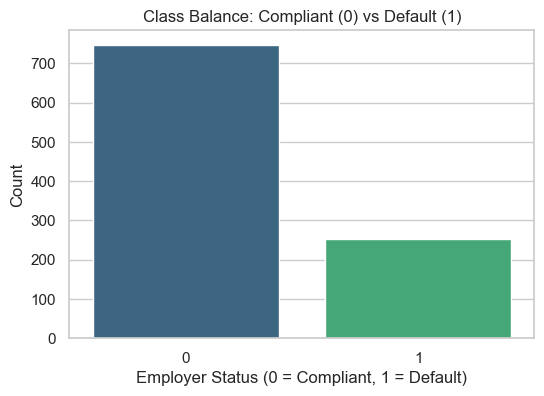

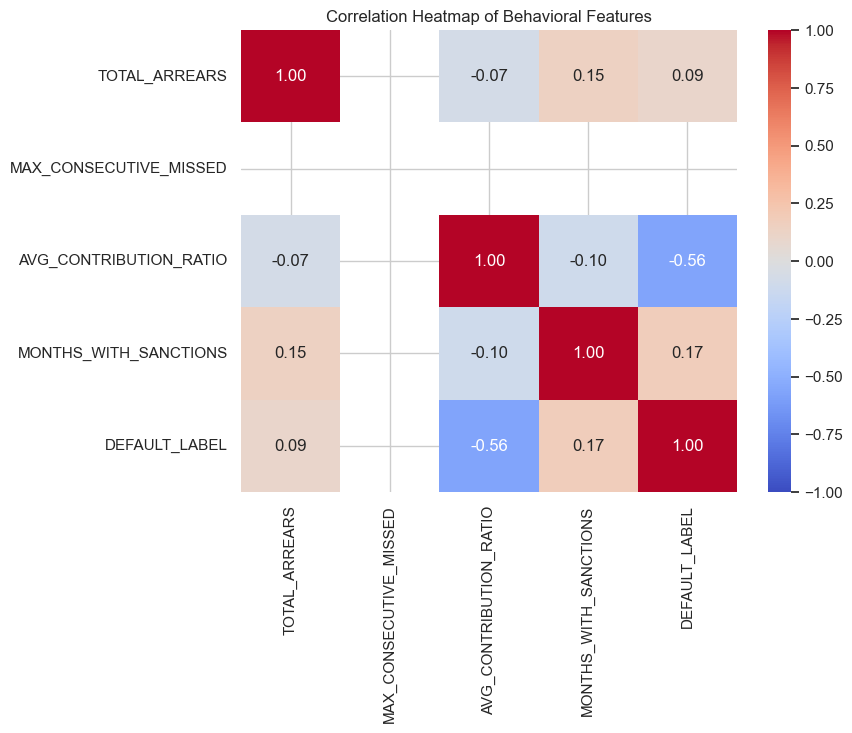

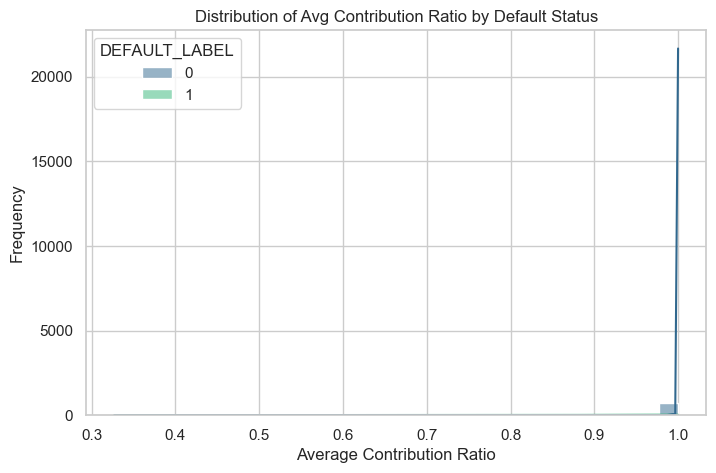

In [7]:
# Visualizing the class balance
plt.figure(figsize=(6, 4))
sns.countplot(data=final_features, x='DEFAULT_LABEL', palette='viridis')
plt.title('Class Balance: Compliant (0) vs Default (1)')
plt.xlabel('Employer Status (0 = Compliant, 1 = Default)')
plt.ylabel('Count')
plt.show()


# Correlation heatmap excluding categorical identifiers
plt.figure(figsize=(8, 6))
correlation_matrix = final_features.drop('EMPLOYER ID', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Behavioral Features')
plt.show()


# Looking at how average contribution ratios differ between defaulters and compliant employers
plt.figure(figsize=(8, 5))
sns.histplot(data=final_features, x='AVG_CONTRIBUTION_RATIO', hue='DEFAULT_LABEL', kde=True, palette='viridis', bins=30)
plt.title('Distribution of Avg Contribution Ratio by Default Status')
plt.xlabel('Average Contribution Ratio')
plt.ylabel('Frequency')
plt.show()